## Introduction 

Our group implemented a natural language processing system to predict ratings from 1 to 5 using the Netflix reviews dataset. The project incorporated the Term Frequency–Inverse Document Frequency (TF-IDF) approach, which helps measure how frequently words appear and determines their relevance within Netflix reviews. After applying TF-IDF, we fitted the model using the Support Vector Machines (SVM) approach. After training, fitting, and evaluating the model, our results will show the accuracy in predicting review ratings based on the textual features extracted from the dataset.

We were interested in working with a large dataset, such as the Netflix reviews dataset, because it helped us understand the fundamentals of natural language processing when working with text-based data. The Netflix reviews dataset is flexible and well-suited for applying NLP techniques, allowing us to efficiently process, analyze, and model textual information for rating prediction.


## Data description 

We obtained the Netflix reviews dataset by downloading it from Kaggle, a platform for accessing free public datasets. This dataset includes user reviews, ratings, and review dates, making it suitable for text-based analysis. Our primary focus is on the rating (score) variable, which we aim to predict using natural language processing techniques. Therefore, we drop the other variables and retain only the text reviews and corresponding scores for modeling. The link to the dataset can be found here. (ADD LINK) 

Now, we'll load in the necessary libraries and read in our data.

In [61]:
import pandas as pd
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, opinion_lexicon
import string
from nltk.stem import PorterStemmer
from nltk.util import ngrams
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from wordcloud import WordCloud
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("netflix_reviews.csv")


## Methods:

In this section, we perform the preliminary data preprocesisng and explanatory data analysis (EDA) needed before testing our model. We'll made sure our data is clean by removing missing values and formatted correctly so the model can run successfully. We also will remove stop words so that they aren't included content_tokenized column, and created another column in the sample of the words from the cleaned content column as string columns. In order to ensure improved readability, we swapped the orders of the columns to the order of content_tokenized, content_string, and score.

In [62]:
df.columns

Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='str')

There are several columns in this dataset, but we only need `content` and `score` for our purposes, so we can drop the others.

In [63]:
df = df.drop(columns = ['reviewId', 'userName', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'appVersion'])

Since this is a very large dataset, we'll just take a sample of 10000 reviews. 

In [64]:
# making a sample of 10000 entries from the dataset
sample, _ = train_test_split(df, train_size = 10000, stratify = df['score'], random_state = 42)
sample.reset_index(drop = True, inplace = True)

In [65]:
df.isna().sum()

content    6
score      0
dtype: int64

Our sample is very large, so we can afford to drop the few rows that contains null values. Additionally, we'll remove any puncuation symbols that are present in the reviews, since they don't have any predictive power. Finally, we'll convert all the text to lowercase, which ensures we won't have multiple versions of the same word.

In [66]:
# droping null values, removing punctuation, and converting to lowercase
sample = sample.dropna()
sample['content'] = sample['content'].str.replace(r"[^A-Za-z\s]", "", regex=True).str.lower()

Now, we create a new column in which each entry is a list of all the tokenized words from that review. We drop the old column `content` since it won't be needed anymore. 

In [67]:
# making a new column which has a list of all words in that row's content column and then dropping the content column
sample['content_tokenized'] = sample['content'].apply(word_tokenize) 
sample = sample.drop(columns = ['content'])

We'll load in a set of predefined stop words, and iterate through our tokenized review column, removing any of the stopwords we find.

In [68]:
# defining set of stopwords
stop_words = set(stopwords.words('english'))

# defining function to remove stop words
def remove_stop(review):
    filtered = [word for word in review if word not in stop_words]
    return filtered

# removing stop words from content_tokenized column
sample['content_tokenized'] = sample['content_tokenized'].apply(remove_stop)

Finally, we'll create a new column `content_string` which has all the words remaining for each review joined together as a string. This will be important later on when we calculate our tf-idf scores.

In [69]:
# making another column in sample with the words from the cleaned content column as strings
def into_string(content):
    return " ".join(content)

sample['content_string'] = sample['content_tokenized'].apply(into_string)

# swapping order of columns for improved readablility
sample = sample[['content_tokenized', 'content_string', 'score']]

Below is a bar chart of the 20 most frequently used words. The most common words overall were app, netflix, movies, and watch. This isn’t surprising as these words all fit the context of using the Neflix app.

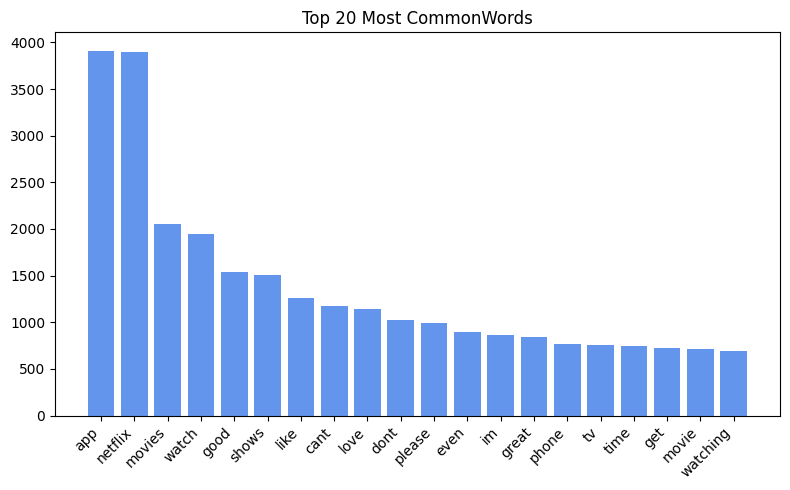

In [70]:
# bar chart for most common words
all_words = [w for tokens in sample['content_tokenized'] for w in tokens]
top_overall = Counter(all_words).most_common(20)

words, counts = zip(*top_overall)
plt.figure(figsize=(8, 5))
plt.bar(words, counts, color='cornflowerblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most CommonWords')
plt.tight_layout()
plt.show()

Next, we grouped the top 20 common words into each group based on their scores. To find what the top 20 common words each score holds. Below is a horizontal bar chart, which has two bar charts of scores 1 and score 5 next to each other. We chose these scores to find the differences between them. After visualizing them, we found that the top 20 common words with a score of 1 included the list of app, netflix, cant, and watch. While the top 20 common words with a score of 5 included the list of words of Netflix, app, movies, and love. 


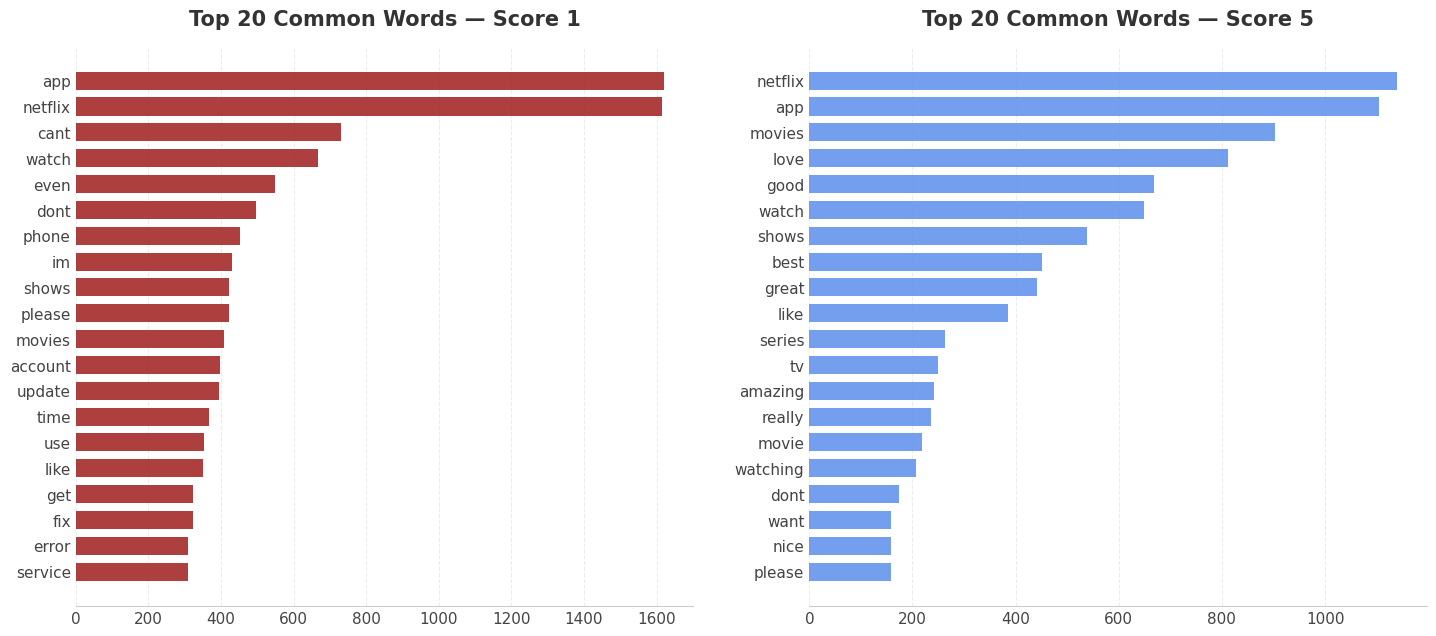

In [71]:
# bar chart for most common words of the highest and lowest scores
score_colors = {1: 'brown', 5: 'cornflowerblue'}
fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)

for ax, score in zip(axes, [1, 5]):
    words_score = [
        w for tokens in sample[sample['score'] == score]['content_tokenized']
        for w in tokens
    ]
    # Keep it to top 20, but reverse it for barh so the highest count is at the top
    top = Counter(words_score).most_common(20)
    w, c = zip(*top)
    w, c = list(w)[::-1], list(c)[::-1] 
    
    # Draw horizontal bars
    ax.barh(w, c, color=score_colors[score], alpha=0.9, height=0.7)
    
    # Title formatting
    ax.set_title(f'Top 20 Common Words — Score {score}', fontsize=15, pad=15, weight='bold', color='#333333')
    
    # Clean up tick parameters
    ax.tick_params(axis='both', which='both', length=0, labelsize=11, colors='#444444')
    
    ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#E0E0E0')
    ax.set_axisbelow(True) # Ensures gridlines sit behind bars
    
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC') # Mute the bottom axis line
plt.tight_layout(pad=3.0)
plt.show()

An alternative method for visualizing the most common words is using a wordcloud, as shown below

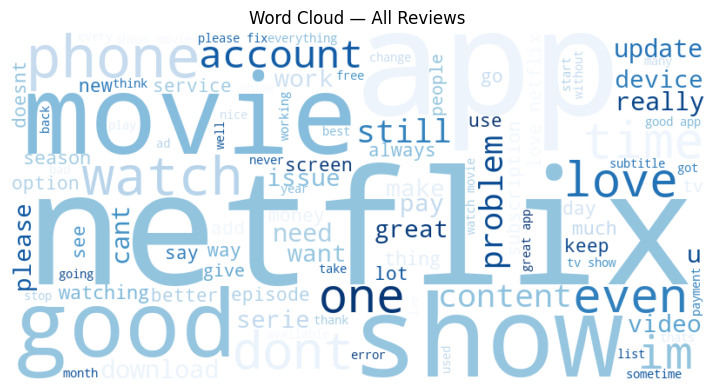

In [72]:
# word cloud for most common-occurring words
text_all = ' '.join(
    w for tokens in sample['content_tokenized']
    for w in tokens
)
wc = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Blues',
    max_words=100
).generate(text_all)

plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Reviews')
plt.tight_layout()
plt.show()

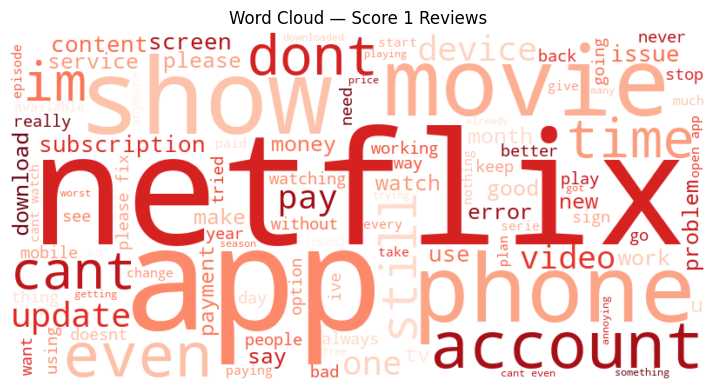

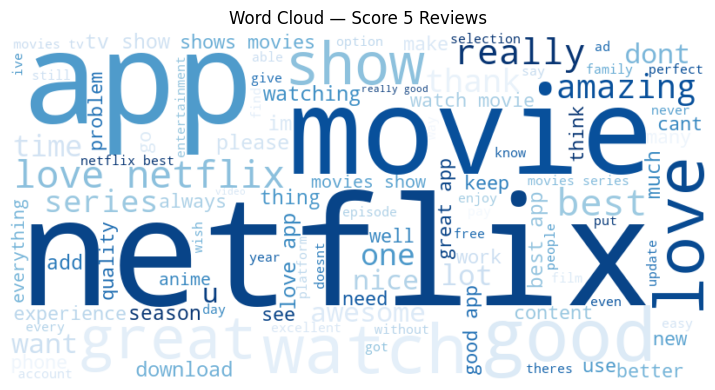

In [73]:
# word cloud for most common words of the highest and lowest scores
cloud_colormaps = {1: 'Reds', 5: 'Blues'}

for score in [1, 5]:
    text = ' '.join(
        w for tokens in sample[sample['score'] == score]['content_tokenized']
        for w in tokens
    )
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=cloud_colormaps[score],
        max_words=100
    ).generate(text)
    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud — Score {score} Reviews')
    plt.tight_layout()
    plt.savefig(f'wordcloud_score_{score}.png', dpi=150)
    plt.show()

Now we'll calculate the TF-IDF scores for each word across all the documents. These scores are what we'll use for predicting the ratings given to the app.

In [74]:
# Calculate TF-IDF values for all words in the dataset
tfidf_vectorizer = TfidfVectorizer(max_features=None)  # Keep all features
tfidf_matrix = tfidf_vectorizer.fit_transform(sample['content_string'])

# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calculate mean TF-IDF values for each word across all documents
tfidf_mean = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Create a DataFrame with words and their mean TF-IDF values
tfidf_df = pd.DataFrame({
    'word': feature_names,
    'mean_tfidf': tfidf_mean
}).sort_values('mean_tfidf', ascending=False)

print(f"Total number of unique words: {len(tfidf_df)}")
print("\nTF-IDF Statistics:")
print(tfidf_df['mean_tfidf'].describe())

Total number of unique words: 11388

TF-IDF Statistics:
count    11388.000000
mean         0.000273
std          0.001232
min          0.000006
25%          0.000029
50%          0.000047
75%          0.000110
max          0.044675
Name: mean_tfidf, dtype: float64


Let's see what words have the largest and smallest TF-IDF values

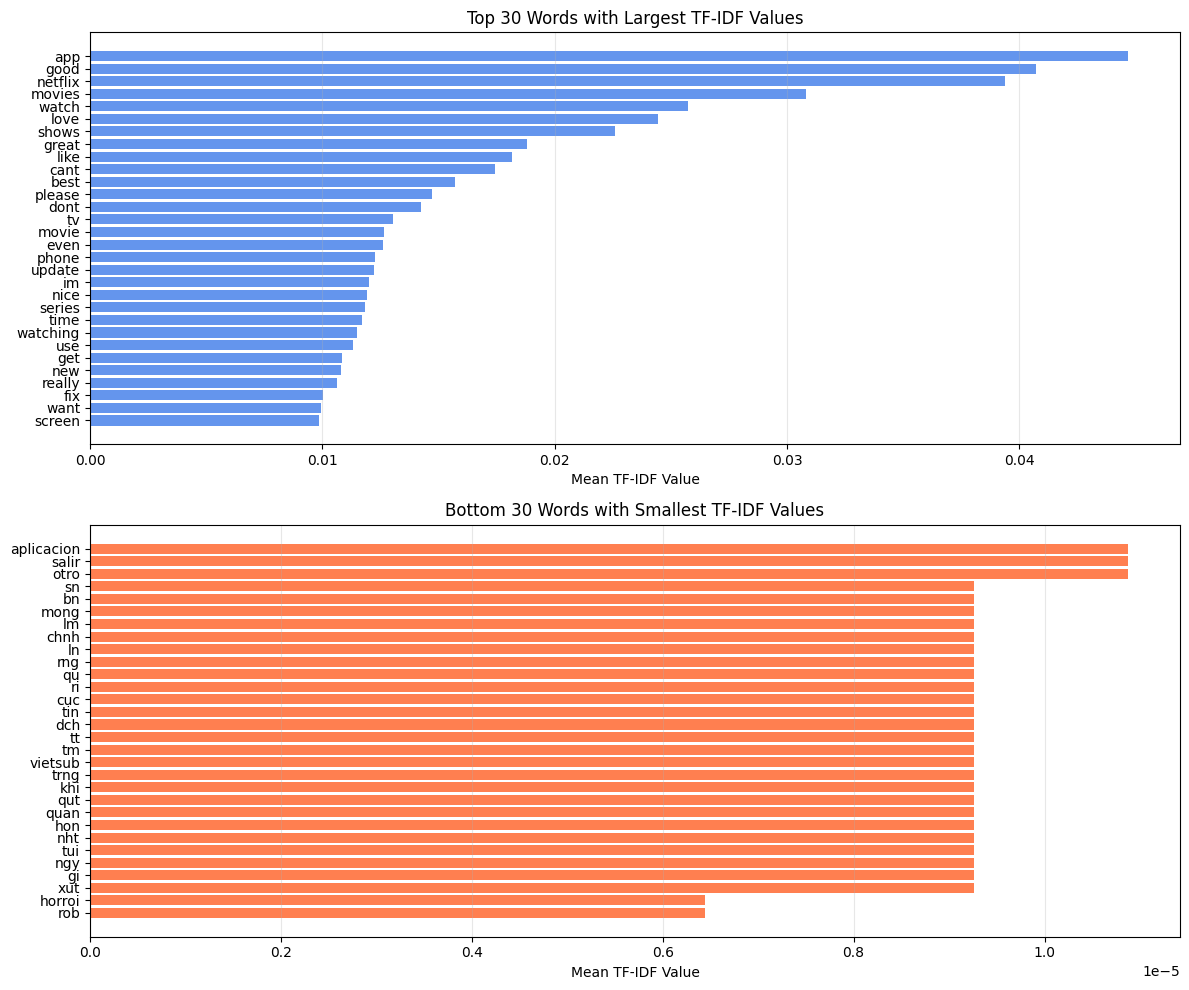

In [75]:
# Top 30 words with largest TF-IDF values
top_30_tfidf = tfidf_df.head(30)

# Bottom 30 words with smallest TF-IDF values
bottom_30_tfidf = tfidf_df.tail(30).sort_values('mean_tfidf', ascending=True)

# Visualization of top and bottom 30 TF-IDF values
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top 30
top_30_sorted = top_30_tfidf.sort_values('mean_tfidf', ascending=True)
axes[0].barh(top_30_sorted['word'], top_30_sorted['mean_tfidf'], color='cornflowerblue')
axes[0].set_xlabel('Mean TF-IDF Value')
axes[0].set_title('Top 30 Words with Largest TF-IDF Values')
axes[0].grid(axis='x', alpha=0.3)

# Bottom 30
axes[1].barh(bottom_30_tfidf['word'], bottom_30_tfidf['mean_tfidf'], color='coral')
axes[1].set_xlabel('Mean TF-IDF Value')
axes[1].set_title('Bottom 30 Words with Smallest TF-IDF Values')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Many of the the words with high TF-IDF values are the same words that we found to be the most commonly occuring words overall. On the other hand, none of the words with small TF-IDF scores were found to be commonly occuring.

## Model Fitting and Results

First we'll create a dataframe with the TF-IDF scores, which we'll use to create our model.

In [76]:
# creating dataframe with the tf_idf scores for each word for each document
A = pd.DataFrame(tfidf_matrix.toarray(), columns = tfidf_vectorizer.get_feature_names_out())
A.head()

,aa,aaa,aacha,aadmi,aaj,aaja,aakh,aana,aap,aapiam,...,zim,zipcode,zkia,zobies,zoe,zones,zoom,zoomed,zoro,zur
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Now we can create our model. We first split our data, stratifying on the outcome in order to ensure an equal proportion of the five potential
ratings across the training and testing sets. We then drop the columns with zero variance since they do not have any predictive power. 

In [77]:
X_train, X_test, y_train, y_test = train_test_split(A, sample['score'], 
                                                    test_size = 0.25, stratify = sample['score'], random_state = 42)

In [78]:
# dropping zero variance columns
selector = VarianceThreshold()
X_train = selector.fit_transform(X_train)
X_test = selector.transform(X_test)

Now we'll fit our model and evaluate the outcome.

In [79]:
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [80]:
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.6284


To predict user ratings from review text, we trained a Linear Support Vector Classifier (LinearSVC) using TF-IDF scores as features. We chose TF-IDF because it highlights words that are especially important in a given review while downweighting very common terms that appear everywhere. Before fitting the model, we removed zero-variance features words that never appeared in the training set since they carry no predictive value.


On the held-out test set, the model reached an accuracy of 62.84%. This is modest in absolute terms, but still well above the 20% baseline we would expect from random guessing across five rating classes. However, the class distribution in our data is clearly imbalanced: score 1 reviews make up almost 39% of the dataset, while score 2 reviews account for only about 9%. This likely boosts performance on the majority class and hurts it on underrepresented ones.


The following figure shows the confusion matrix of the model's prediction results. From the matrix, it can be seen that the model performs well when dealing with extreme ratings, especially for ratings of 1 and 5, as the corresponding comments often contain more intense positive or negative emotions. However, the model has difficulty in predicting intermediate ratings such as 2, 3, and 4. This indicates that comments with intermediate ratings often contain more ambiguous or difficult-to-classify expressions.

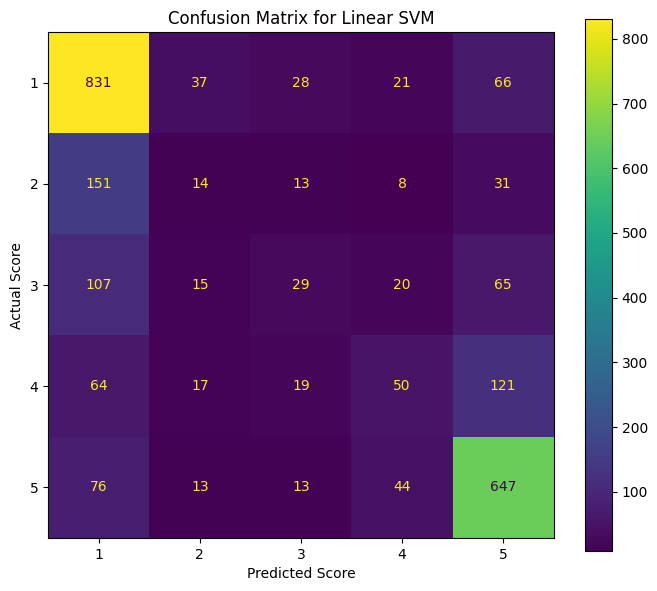

In [81]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)
disp.plot(values_format="d", ax=ax)
ax.set_title("Confusion Matrix for Linear SVM")
ax.set_xlabel("Predicted Score")
ax.set_ylabel("Actual Score")
plt.tight_layout()
plt.savefig("figure_confusion_matrix_linear_svm.png", dpi=300, bbox_inches="tight")
plt.show()

From the prediction results, our model is capable of grasping the overall pattern of the score data, but it tends to predict more frequently those rating categories that occur more frequently and are expressed more clearly. The following graph illustrates the distribution of actual ratings and predicted ratings, showing that our model performs better in identifying extreme positive or negative evaluations, but has a poorer ability to recognize neutral-rated comments.

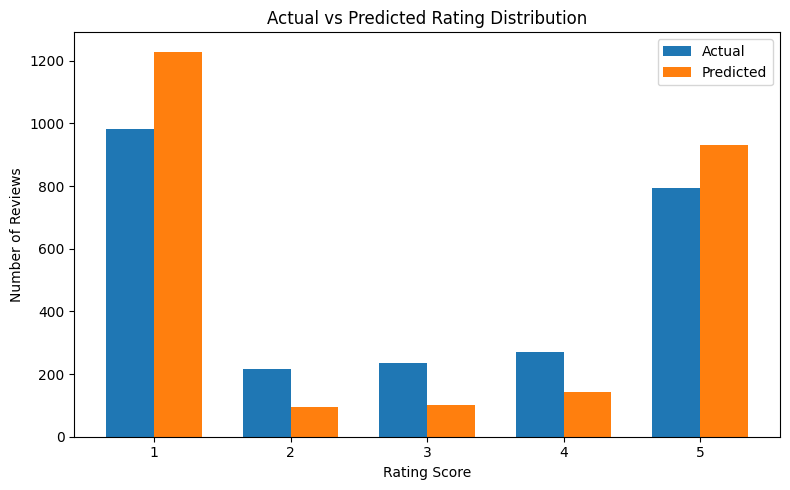

In [82]:
actual_counts = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()
distribution_df = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": predicted_counts
}).fillna(0)

x = np.arange(len(distribution_df.index))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(
    x - width / 2,
    distribution_df["Actual"],
    width,
    label="Actual"
)
plt.bar(
    x + width / 2,
    distribution_df["Predicted"],
    width,
    label="Predicted"
)

plt.xticks(x, distribution_df.index.astype(str))
plt.xlabel("Rating Score")
plt.ylabel("Number of Reviews")
plt.title("Actual vs Predicted Rating Distribution")
plt.legend()

plt.tight_layout()
plt.savefig("figure_actual_vs_predicted_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

In this project, we applied natural language processing techniques to a dataset of Netflix app reviews to build a prediction model of the user-assigned scores based on their review text. After preprocessing the data through tokenization and stop word removal, we did exploratory data analysis by frequency analysis, bigrams, and word clouds, which showed clear linguistic differences between reviews with low and high scores. We then computed TF-IDF scores and trained a Linear Support Vector Machine to classify reviews into five score categories, with a test accuracy of approximately 0.6284.

Future work could explore richer text representations such as word embeddings, which better capture semantic context and word relationships that TF-IDF ignores. Additionally, addressing the class imbalance in the dataset through techniques like class reweighting or sampling could also improve predictions for the ratings. We could also enrich the representation with bigram or trigram features to better capture phrase-level sentiment, and explore non-linear models that might be better suited to the complexity of natural language reviews.